In [ ]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

import sys
import os
sys.path.append(os.path.abspath("../src"))

from utils import get_dataloaders
from model import BrainTumorCNN

<Figure size 1200x1000 with 0 Axes>

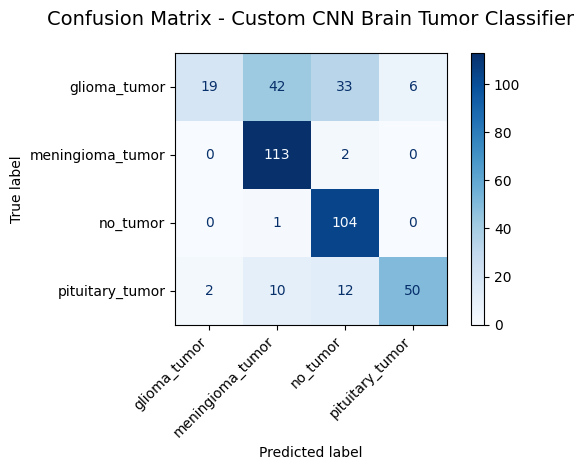

In [ ]:
# Load class names
_, test_loader, class_names = get_dataloaders("../data/brain_tumor_dataset", batch_size=16, model_type="custom")

# Load trained model
model = BrainTumorCNN(num_classes=len(class_names))
model.load_state_dict(torch.load("../cnn_model.pth", map_location="cpu"))  # adjust path if needed
model.eval()

# Get predictions and true labels
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.numpy())

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Plot it
plt.figure(figsize=(12, 10))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Custom CNN Brain Tumor Classifier", fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

                  precision    recall  f1-score   support

    glioma_tumor       0.90      0.19      0.31       100
meningioma_tumor       0.68      0.98      0.80       115
        no_tumor       0.69      0.99      0.81       105
 pituitary_tumor       0.89      0.68      0.77        74

        accuracy                           0.73       394
       macro avg       0.79      0.71      0.68       394
    weighted avg       0.78      0.73      0.68       394

